# 01 — Data Simulation

**Goal.** Generate a 3-year synthetic dataset of daily patient volumes for a Melbourne walk-in clinic (fictional: *Southbank Walk-in Clinic*). We use this synthetic dataset because real urgent-care records aren't publicly shareable, and because simulating the data lets us control the signal-to-noise ratio while we validate the methodology.

**Key drivers baked into the generator:**
- Day of week — Monday heaviest (weekend backlog + GP gap), Friday lightest.
- Seasonality — winter (Jun–Aug) peak driven by flu; summer dip.
- Public holidays — *increase* demand (GPs closed). Day-after also spikes.
- Weather — rainy/cold push respiratory visits up; sunny reduces demand.
- Temperature extremes (both hot and cold) push volume up.
- Hay fever season (Oct–Nov) with a continuous `pollen_index` effect.
- Thunderstorm asthma — rare, high-impact shock events (Melbourne-specific, Nov 2016 precedent).

See `ml-pipeline/src/data/generate_data.py` for the full generator.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.append(str(Path.cwd().parent / 'ml-pipeline' / 'src' / 'data'))
from generate_data import generate_clinic_data

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

In [2]:
df = generate_clinic_data()
df.head()

Generating data from 2023-01-01 to 2025-12-31...

Dataset generated successfully.
Shape: (1096, 31)
Patients — mean: 130  median: 123  min: 51  max: 310
Thunderstorm-asthma events: 1


,date,year,month,day,day_of_week,day_name,week_of_year,quarter,is_public_holiday,is_day_after_public_holiday,...,is_thunderstorm_asthma,illness_driver_count,patients_last_week,patients_last_2weeks,patients_last_month,patients_7day_avg,patients_14day_avg,patients_30day_avg,patients_same_day_last_year,patients
0,2023-01-01,2023,1,1,6,Sunday,52,1,1,0,...,0,0,129.985308,130.050832,130.355535,128.0,128.0,128.0,128.090287,128
1,2023-01-02,2023,1,2,0,Monday,1,1,1,1,...,0,1,129.985308,130.050832,130.355535,158.0,158.0,158.0,128.090287,188
2,2023-01-03,2023,1,3,1,Tuesday,1,1,0,1,...,0,1,129.985308,130.050832,130.355535,142.0,142.0,142.0,128.090287,110
3,2023-01-04,2023,1,4,2,Wednesday,1,1,0,0,...,0,0,129.985308,130.050832,130.355535,126.5,126.5,126.5,128.090287,80
4,2023-01-05,2023,1,5,3,Thursday,1,1,0,0,...,0,0,129.985308,130.050832,130.355535,117.6,117.6,117.6,128.090287,82


In [3]:
print(f'Shape: {df.shape}')
print(f'Date range: {df.date.min().date()} → {df.date.max().date()}')
print()
print('Patients summary:')
print(df['patients'].describe().round(1))

Shape: (1096, 31)
Date range: 2023-01-01 → 2025-12-31

Patients summary:
count    1096.0
mean      130.2
std        39.5
min        51.0
25%       102.0
50%       123.0
75%       150.0
max       310.0
Name: patients, dtype: float64


## Time series overview

Daily counts (grey) with a 30-day moving average (red) to reveal seasonal structure.

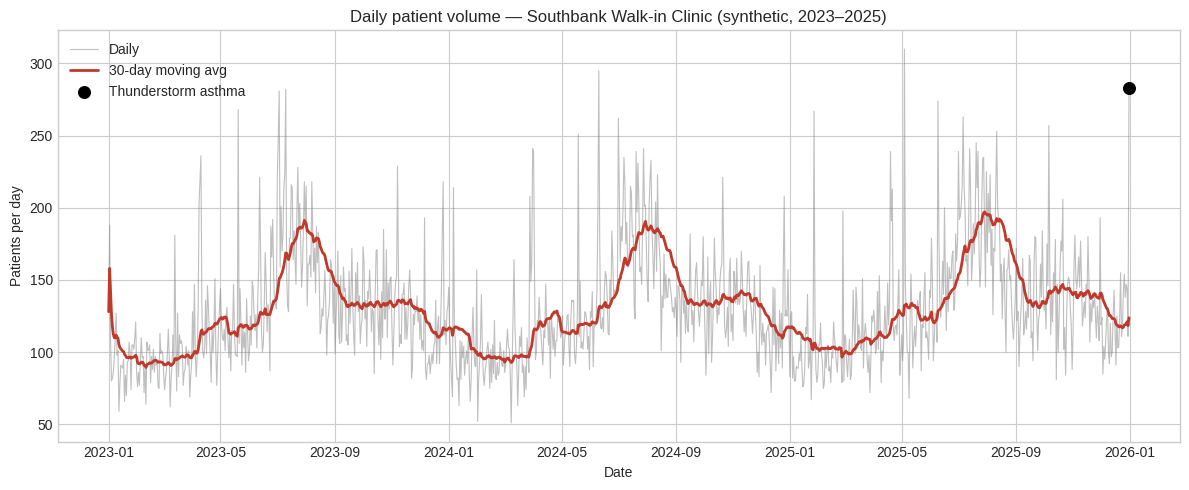

In [4]:
df_ts = df.set_index('date')
ma30 = df_ts['patients'].rolling(30, min_periods=1).mean()

fig, ax = plt.subplots()
ax.plot(df_ts.index, df_ts['patients'], color='grey', alpha=0.5, linewidth=0.8, label='Daily')
ax.plot(ma30.index, ma30.values, color='#c0392b', linewidth=2, label='30-day moving avg')

shock = df_ts[df_ts['is_thunderstorm_asthma'] == 1]
ax.scatter(shock.index, shock['patients'], color='black', zorder=5, s=70, label='Thunderstorm asthma')

ax.set_title('Daily patient volume — Southbank Walk-in Clinic (synthetic, 2023–2025)')
ax.set_ylabel('Patients per day')
ax.set_xlabel('Date')
ax.legend()
plt.tight_layout()
plt.show()

## Target distribution

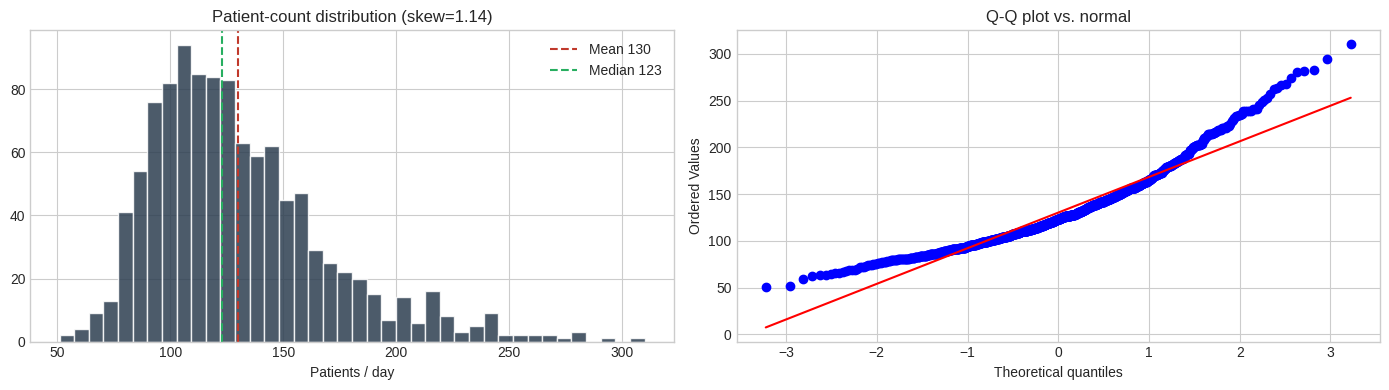

In [5]:
from scipy import stats

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['patients'], bins=40, color='#2c3e50', alpha=0.85, edgecolor='white')
axes[0].axvline(df['patients'].mean(), color='#c0392b', linestyle='--', label=f"Mean {df['patients'].mean():.0f}")
axes[0].axvline(df['patients'].median(), color='#27ae60', linestyle='--', label=f"Median {df['patients'].median():.0f}")
axes[0].set_title(f"Patient-count distribution (skew={stats.skew(df['patients']):.2f})")
axes[0].set_xlabel('Patients / day')
axes[0].legend()

stats.probplot(df['patients'], dist='norm', plot=axes[1])
axes[1].set_title('Q-Q plot vs. normal')
plt.tight_layout()
plt.show()

The distribution is right-skewed — typical for demand data. A `log1p` transform will be applied during modelling to stabilise variance.

In [6]:
out_dir = Path.cwd().parent / 'data' / 'raw'
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / 'clinic_patients_melbourne.csv'
df.to_csv(out_path, index=False)
print(f'Saved → {out_path}')

Saved → /home/wandabwa2004/Projects/urgent-care-demand-forecast/data/raw/clinic_patients_melbourne.csv
